In [ ]:
#lưu file zip của nhánh feature/eda trên github về Drive để mở
from google.colab import drive
drive.mount('/content/drive')

!find /content/drive/MyDrive/stock_price -name "stock-price-prediction-feature-eda.zip"

!cp "/content/drive/MyDrive/stock_price/stock-price-prediction-feature-eda.zip" ./data.zip
!unzip -q data.zip

print("Unzip thành công")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/stock_price/stock-price-prediction-feature-eda.zip
replace stock-price-prediction-feature-eda/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: Unzip thành công


In [ ]:
%cd /content/stock-price-prediction-feature-eda
!pwd

/content/stock-price-prediction-feature-eda
/content/stock-price-prediction-feature-eda


In [ ]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
from src.data.crawl import config as cfg

#PATHS
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_STOCK_DIR = PROCESSED_DIR / "stock"
PROCESSED_MARKET_DIR = PROCESSED_DIR / "market"
PREPROCESSED_DIR=PROJECT_ROOT/"preprocess"

#COLUMNS
OHLCV_COLS = ["open", "high", "low", "close", "volume"]
QUALITY_COLS = [
    "missing_ohlc",
    "non_positive_ohlc",
    "high_invalid",
    "low_invalid",
    "ohlc_invalid",
    "zero_volume",
    "missing_volume"
]
EVENT_COLS = [
    "hose_disruption",
]
DERIVED_COLS = [
  "log_close","return","log_return","range_pct","traded_value","open_close_pct",
  "volatility_5d","volatility_20d", "realized_vol_20d","sma_5",
  "sma_20","ema_5","ema_20","close_vs_sma5","close_vs_sma20","momentum_5d", "momentum_20d",
  "atr_14_pct","volume_sma_20","rsi_14","lag_return_1","lag_return_5","atr_14",
  "excess_return_vnindex","excess_return_vn30","vnindex_log_return","vn30_log_return"]
HOSE_DISRUPTION_DATES = pd.to_datetime([
    "2018-01-23",
    "2018-01-24",
])

#RAW DATA + CLEANING DATA
def ensure_ohlcv_columns(df: pd.DataFrame) -> pd.DataFrame:
  #Các cột chuyển về dạng số: k có value-> NaN
    df = df.copy()
    for col in OHLCV_COLS:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def load_raw_stock(code: str) -> pd.DataFrame:
    #Load raw stock CSV and normalize schema
    df = pd.read_csv(Path(cfg.RAW_STOCK_DIR)/ f"{code}.csv")
    df = df.rename(columns={"time": "trading_date"})
    df["trading_date"] = pd.to_datetime(df["trading_date"])
    df = ensure_ohlcv_columns(df)
    df = (
        df.sort_values("trading_date")
        .drop_duplicates("trading_date", keep="first")
        .reset_index(drop=True)
    )
    return df

def load_raw_market(symbol: str) -> pd.DataFrame:
    #Load raw market index CSV and normalize schema
    df = pd.read_csv(Path(cfg.RAW_MARKET_DIR) / f"{symbol}.csv")
    df = df.rename(columns={"time": "trading_date", "index": "index_code"})
    df["trading_date"] = pd.to_datetime(df["trading_date"])
    df = ensure_ohlcv_columns(df)
    df = (
        df.sort_values("trading_date")
        .drop_duplicates("trading_date", keep="first")
        .reset_index(drop=True)
    )
    return df

#QUALITY + EVENT FLAGS
def add_quality_flags(df: pd.DataFrame) -> pd.DataFrame:
  #flag: Missing value trong OHLC/<=0 value/'high' không cao nhất/'low' không nhỏ nhất
    df = df.copy()
    ohlc = ["open", "high", "low", "close"]
    df["missing_ohlc"] = df[ohlc].isna().any(axis=1).astype(int)
    df["non_positive_ohlc"] = (df[ohlc] <= 0).any(axis=1).astype(int)
    df["high_invalid"] = (
        (df["high"] < df["open"])
        | (df["high"] < df["close"])
        | (df["high"] < df["low"])
    ).astype(int)
    df["low_invalid"] = (
        (df["low"] > df["open"])
        | (df["low"] > df["close"])
        | (df["low"] > df["high"])
    ).astype(int)
    df["ohlc_invalid"] = (
        df["missing_ohlc"].eq(1)
        | df["non_positive_ohlc"].eq(1)
        | df["high_invalid"].eq(1)
        | df["low_invalid"].eq(1)
    ).astype(int)
    if "volume" in df.columns:
        df["zero_volume"] = df["volume"].eq(0).astype(int)
        df["missing_volume"] = df["volume"].isna().astype(int)
    else:
        df["zero_volume"] = 0
        df["missing_volume"] = 0
    return df

def add_event_flags(df: pd.DataFrame) -> pd.DataFrame:
  #event flag: các sự kiện gián đoạn giao dịch
  #HOSE disruption: 23-24/1/2018
    df = df.copy()
    df["hose_disruption"] = (
        df["trading_date"].isin(HOSE_DISRUPTION_DATES)
    ).astype(int)
    return df

#FEATURES
#một vài features cho model học
def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = add_quality_flags(df)
    df = add_event_flags(df)

    bad_data_mask = (df["ohlc_invalid"].eq(1)) | (df["hose_disruption"].eq(1)) | (df["zero_volume"].eq(1))| df["missing_volume"].eq(1)

    df_clean_time = df.copy()
    df_clean_time.loc[bad_data_mask, OHLCV_COLS] = np.nan
    df_clean_time[OHLCV_COLS[:4]] = df_clean_time[OHLCV_COLS[:4]].ffill()
    #Close-based
    valid_close = df_clean_time["close"].gt(0) & df_clean_time["close"].notna()
    df["log_close"] = np.where(valid_close, np.log(df_clean_time["close"]), np.nan)
    df["return"] = df_clean_time["close"].pct_change()
    df["log_return"] = pd.Series(df["log_close"], index=df.index).diff()
    #OHLC based
    clean_ohlc = df[["open", "high", "low", "close"]].mask(bad_data_mask)
    df["range_pct"] = (clean_ohlc["high"] - clean_ohlc["low"]) / clean_ohlc["close"]
    df["open_close_pct"] = (clean_ohlc["close"] - clean_ohlc["open"]) / clean_ohlc["open"]
    #votality+ATR
    df["volatility_5d"] = (df["log_return"].rolling(5).std())
    df["volatility_20d"] = (df["log_return"].rolling(20).std())
    df["realized_vol_20d"] = np.sqrt((df["log_return"] ** 2).rolling(20).sum())

    high_low = df_clean_time["high"] - df_clean_time["low"]
    high_close_prev = (df_clean_time["high"] - df_clean_time["close"].shift(1)).abs()
    low_close_prev = (df_clean_time["low"] - df_clean_time["close"].shift(1)).abs()
    df["true_range"] = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)

    window = 14
    df["atr_14"] = df["true_range"].ewm(alpha=1/window, adjust=False).mean()
    df["atr_14_pct"] = df["atr_14"] / df_clean_time["close"]
    df.drop(columns=["true_range"], inplace=True)

    # Trend + Momentum
    df["sma_5"] = df_clean_time["close"].rolling(5).mean()
    df["sma_20"] = df_clean_time["close"].rolling(20).mean()
    df["ema_5"] = df_clean_time["close"].ewm(span=5, adjust=False).mean()
    df["ema_20"] = df_clean_time["close"].ewm(span=20, adjust=False).mean()
    df["close_vs_sma5"] = (df_clean_time["close"] / df["sma_5"]) - 1
    df["close_vs_sma20"] = (df_clean_time["close"] / df["sma_20"]) - 1
    df["momentum_5d"] = (df_clean_time["close"] / df_clean_time["close"].shift(5)) - 1
    df["momentum_20d"] = (df_clean_time["close"] / df_clean_time["close"].shift(20)) - 1

    # Volume-based feature
    if "volume" in df.columns:
        df["traded_value"] = df_clean_time["close"] * df_clean_time["volume"]
        df["volume_sma_20"] = df_clean_time["volume"].rolling(20).mean()

    # RSI
    delta = df_clean_time["close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))

    # Lag
    df["lag_return_1"] = df["log_return"].shift(1)
    df["lag_return_5"] = df["log_return"].shift(5)

    return df

def add_market_related_features(stock_df: pd.DataFrame,vnindex_df: pd.DataFrame,vn30_df: pd.DataFrame) -> pd.DataFrame:

    df = stock_df.copy()
    vnindex = (vnindex_df[["trading_date", "log_return"]].rename(columns={"log_return": "vnindex_log_return"}))
    vn30 = (vn30_df[["trading_date", "log_return"]].rename(columns={"log_return": "vn30_log_return"}))
    df = df.merge(vnindex,on="trading_date", how="left")
    df = df.merge(vn30,on="trading_date",how="left")
    # excess return so với toàn thị trường
    df["excess_return_vnindex"] = (df["log_return"]-df["vnindex_log_return"])
    # excess return so với nhóm bluechip
    df["excess_return_vn30"] = (df["log_return"]-df["vn30_log_return"])
    return df

#TARGET COLUMN
#log_return mới là thứ mà model dự đoán chứ không phải price thuần (log_return có thể xem đại khái như tỉ lệ giá tăng)
def add_target_columns(df:pd.DataFrame) -> pd.DataFrame:
    df=df.copy()

    df["target_log_return_1d"] = df["log_return"].shift(-1) #D1 biết độ tăng D0->D1 là 1% thì D2 predict độ tăng từ D1->D2
    df["target_log_return_5d"] = (df["log_return"].rolling(5).sum().shift(-5)) #nghĩa là giá tăng bao nhiêu sau 5 ngày
    df["target_log_return_20d"] = (df["log_return"].rolling(20).sum().shift(-20)) #sau 20 ngày

    return df

#HANDLE FLAGS
def handle_flag(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    flag_days = ((df["ohlc_invalid"] == 1) | (df["hose_disruption"] == 1) | (df["zero_volume"] == 1) |(df["missing_volume"] == 1))
    df = df[~flag_days]
    essential_features = DERIVED_COLS
    df = df.dropna(subset=essential_features)
    target_cols = ["target_log_return_1d", "target_log_return_5d", "target_log_return_20d"]
    df = df.dropna(subset=target_cols)
    return df.reset_index(drop=True)

def preprocess(stock_code: str, vnindex_market_df: pd.DataFrame,vn30_market_df) -> pd.DataFrame:
    df = load_raw_stock(stock_code)
    df = add_derived_columns(df)
    df = add_market_related_features(df, vnindex_market_df,vn30_market_df)
    df = add_target_columns(df)
    df_clean = handle_flag(df)
    return df_clean

#MAIN
def main() -> None:
    PROCESSED_STOCK_DIR.mkdir(parents=True, exist_ok=True)
    PROCESSED_MARKET_DIR.mkdir(parents=True, exist_ok=True)
    PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)

    vnindex_market_df = load_raw_market("VNINDEX")
    vnindex_market_df = add_derived_columns(vnindex_market_df)
    vnindex_market_df.to_csv(PROCESSED_MARKET_DIR / "VNINDEX_processed.csv", index=False)

    vn30_market_df = load_raw_market("VN30")
    vn30_market_df = add_derived_columns(vn30_market_df)
    vn30_market_df.to_csv(PROCESSED_MARKET_DIR / "VN30_processed.csv", index=False)

    sample_stocks = ["FPT","HPG","VCB","VIC","VNM"]

    processed_df=dict()
    for code in sample_stocks:
        processed_df[code] = preprocess(code, vnindex_market_df, vn30_market_df)

    #Nếu train riêng trên từng mã thỉ bỏ từ đoạn này tới dòng comment tiếp theo
    common_dates = set(processed_df[sample_stocks[0]]["trading_date"])
    for code in sample_stocks[1:]:
        common_dates &= set(processed_df[code]["trading_date"])

    common_dates = sorted(common_dates)

    for code, df in processed_df.items():
        df = df[df["trading_date"].isin(common_dates)]
        #bỏ tới đây
        output_file = PREPROCESSED_DIR / f"{code}_preprocessed.csv"
        df.to_csv(output_file, index=False)
        print(f"Đã xuất file: {output_file}")

if __name__ == "__main__":
    main()

Đã xuất file: /content/stock-price-prediction-feature-eda/preprocess/FPT_preprocessed.csv
Đã xuất file: /content/stock-price-prediction-feature-eda/preprocess/HPG_preprocessed.csv
Đã xuất file: /content/stock-price-prediction-feature-eda/preprocess/VCB_preprocessed.csv
Đã xuất file: /content/stock-price-prediction-feature-eda/preprocess/VIC_preprocessed.csv
Đã xuất file: /content/stock-price-prediction-feature-eda/preprocess/VNM_preprocessed.csv


In [ ]:
tickers = ["FPT","HPG","VCB","VIC","VNM"]
dfs = []

for ticker in tickers:
    file_path = PREPROCESSED_DIR / f"{ticker}_preprocessed.csv"
    df = pd.read_csv(file_path)
    df["trading_date"] = pd.to_datetime(df["trading_date"])
    df["ticker"] = ticker
    dfs.append(df)

all_df = pd.concat(dfs,ignore_index=True)
all_df = (all_df.sort_values(["trading_date", "ticker"]).reset_index(drop=True))

print(all_df.shape)
print(all_df.head())

(17155, 46)
  stock_code trading_date   open   high    low  close  volume  missing_ohlc  \
0        FPT   2012-02-07   4.23   4.27   4.18   4.23   74910             0   
1        HPG   2012-02-07   0.80   0.81   0.79   0.80  563860             0   
2        VCB   2012-02-07   5.55   5.62   5.44   5.55  502100             0   
3        VIC   2012-02-07   9.84  10.01   9.59   9.76   74480             0   
4        VNM   2012-02-07  12.72  12.72  12.64  12.72   52570             0   

   non_positive_ohlc  high_invalid  ...  lag_return_1  lag_return_5  \
0                  0             0  ...      0.000000     -0.004796   
1                  0             0  ...      0.038221      0.000000   
2                  0             0  ...     -0.007233      0.009083   
3                  0             0  ...      0.034112      0.008840   
4                  0             0  ...     -0.005488      0.012005   

   vnindex_log_return  vn30_log_return  excess_return_vnindex  \
0            0.003372

In [ ]:
#Time series split/forward chaining
from sklearn.model_selection import TimeSeriesSplit
dates = np.sort(all_df["trading_date"].unique())

target='target_log_return_20d'
tscv = TimeSeriesSplit(n_splits=3,gap=20) #gap=20/21 để tránh leakage nhé, có thể đổi theo target

for fold, (train_date_idx, test_date_idx) in enumerate(tscv.split(dates)):
    train_dates = dates[train_date_idx]
    test_dates = dates[test_date_idx]
    train_df = all_df[all_df["trading_date"].isin(train_dates)]
    test_df = all_df[all_df["trading_date"].isin(test_dates)]
    print(f"Fold {fold+1}: "f"train={len(train_df)}, "f"test={len(test_df)}")

Fold 1: train=4200, test=4285
Fold 2: train=8485, test=4285
Fold 3: train=12770, test=4285


In [ ]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV
# scaler
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
import numpy as np
from scipy import stats
import pandas as pd

# Parameter distributions for RandomizedSearchCV
param_distributions = {
    "svr__kernel": ["rbf", "linear", "poly"],
    "svr__C": stats.loguniform(0.01, 100),
    "svr__epsilon": stats.uniform(0.001, 0.5),
    "svr__gamma": ["scale", "auto"] + list(stats.loguniform(0.0001, 1).rvs(5))
}

def get_label(train_df:pd.DataFrame, day:int = 20):
    target_cols = ["target_log_return_1d", "target_log_return_5d", "target_log_return_20d"]
  #bỏ cột target, cột mã và cột ngày tháng
    non_feature_cols = ["stock_code", "trading_date", "ticker"] + target_cols
    features = [col for col in train_df.columns if col not in non_feature_cols]
    train_data = train_df[features]
    label = train_df[f"target_log_return_{day}d"]
    return train_data, label

def get_pipeline(scaler, model):
    return make_pipeline(scaler, model)

def train(X_train: pd.DataFrame, y_train: pd.DataFrame, scaler, model, param_distributions):
    pipeline = get_pipeline(scaler, model)
    random_search = RandomizedSearchCV(pipeline, param_distributions, n_iter=75, cv=None, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1, random_state=42)
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_

In [ ]:
import warnings
warnings.filterwarnings('ignore')

days_to_predict = [1, 5, 20]
scaler = MinMaxScaler((0,1))
model = SVR()

best_estimators_per_target_and_fold = {}
for day in days_to_predict:
    print(f"\nTraining for target: target_log_return_{day}d")
    best_estimators_for_current_target = {}

    for fold, (train_date_idx, test_date_idx) in enumerate(tscv.split(dates)):
        train_dates = dates[train_date_idx]
        train_df_fold = all_df[all_df["trading_date"].isin(train_dates)].copy()

        X_train, y_train = get_label(train_df_fold, day=day)
        print(f"  Fold {fold+1}: Training with {len(X_train)} samples for target_log_return_{day}d")

        best_estimator = train(X_train, y_train, scaler, model, param_distributions)
        best_estimators_for_current_target[f"fold_{fold+1}"] = best_estimator
        print(f"  Fold {fold+1} Best Parameters: {best_estimator.named_steps['svr'].get_params()}")

    best_estimators_per_target_and_fold[f"target_{day}d"] = best_estimators_for_current_target

print("\nTraining complete! Best estimators stored in 'best_estimators_per_target_and_fold'.")


Training for target: target_log_return_1d
  Fold 1: Training with 4200 samples for target_log_return_1d
Fitting 5 folds for each of 75 candidates, totalling 375 fits
  Fold 1 Best Parameters: {'C': np.float64(0.012637946338082878), 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': np.float64(0.054945713496652226), 'gamma': np.float64(0.014032889855919224), 'kernel': 'poly', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}
  Fold 2: Training with 8485 samples for target_log_return_1d
Fitting 5 folds for each of 75 candidates, totalling 375 fits
  Fold 2 Best Parameters: {'C': np.float64(0.01088399181393813), 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': np.float64(0.05173577143301605), 'gamma': np.float64(0.0064872472786873135), 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}
  Fold 3: Training with 12770 samples for target_log_return_1d
Fitting 5 folds for each of 75 candidates, totalling 375 fits
  Fold 3 Best Pa

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white
import scipy.stats as stats
import statsmodels.api as sm
import pandas as pd
import numpy as np

def evaluate_model(target_day_full_name, best_estimators_dict, all_df, tscv, dates):
    results = []
    all_residuals = []

    print(f"Evaluating Target: {target_day_full_name}")
    day_num = int(target_day_full_name.replace('target_log_return_', '').replace('d', ''))

    for fold, (train_idx, test_idx) in enumerate(tscv.split(dates)):
        test_dates_fold = dates[test_idx]
        test_df_fold = all_df[all_df['trading_date'].isin(test_dates_fold)].copy()

        X_test, y_true = get_label(test_df_fold, day=day_num)

        # Get model for this specific fold
        model = best_estimators_dict[f'fold_{fold+1}']
        y_pred = model.predict(X_test)

        # Basic Metrics
        mse = mean_squared_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred) if not y_true.empty else float('nan') # Handle empty case for MAPE
        r2 = r2_score(y_true, y_pred)

        # Residuals
        residuals = y_true - y_pred
        all_residuals.extend(residuals)

        # Prepare X_test for White Test
        X_test_for_white = X_test.select_dtypes(include=np.number).copy()
        # Drop columns that are constant or have very low variance (near constant)
        for col in X_test_for_white.columns:
            if X_test_for_white[col].nunique(dropna=False) <= 1:
                X_test_for_white = X_test_for_white.drop(columns=[col])

        # Add a constant to the cleaned X_test for the White Test
        X_test_with_const = None
        if X_test_for_white.shape[1] > 0:
            # Add constant, ensuring it's not added if all features are dropped
            X_test_with_const = sm.add_constant(X_test_for_white, has_constant='add', prepend=False)
        else:
            # if no features, use a constant for the X_test for white test (will be skipped later)
            X_test_with_const = pd.DataFrame(index=X_test.index, data={'const': 1}) if not X_test.empty else pd.DataFrame()

        # Drop rows with NaNs from X_test_with_const and corresponding residuals
        # Only proceed if X_test_with_const is not empty
        residuals_clean = pd.Series(residuals)
        if not X_test_with_const.empty:
            combined_data = pd.concat([X_test_with_const, residuals_clean.rename('residuals')], axis=1).dropna()
            X_test_with_const_clean = combined_data.drop(columns=['residuals'])
            residuals_clean = combined_data['residuals']
        else:
            X_test_with_const_clean = pd.DataFrame()
            residuals_clean = pd.Series([])

        # Durbin-Watson
        dw = durbin_watson(residuals)

        # Ljung-Box (H0: residuals are independent)
        lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
        lb_pvalue = lb_test['lb_pvalue'].values[0]

        # White Test for Heteroskedasticity
        white_pvalue = float('nan')
        try:
            # Only perform White test if X_test_with_const_clean has at least two columns (constant + at least one feature)
            # and residuals are not empty
            if X_test_with_const_clean.shape[1] > 1 and not residuals_clean.empty and len(residuals_clean) > X_test_with_const_clean.shape[1]:
                white_test = het_white(residuals_clean, X_test_with_const_clean)
                white_pvalue = white_test[1]
            else:
                print(f"Warning: White test skipped for {target_day_full_name} fold {fold+1} due to insufficient valid features, empty residuals after cleaning, or too few observations. Exog shape: {X_test_with_const_clean.shape}, Residuals count: {len(residuals_clean)}")
        except AssertionError as e:
            print(f"Warning (AssertionError): White test failed for {target_day_full_name} fold {fold+1} due to matrix rank issues. Exog shape: {X_test_with_const_clean.shape}. Error: {e}")
        except Exception as e:
            print(f"Warning (Other Error): White test failed for {target_day_full_name} fold {fold+1}: {e}")

        results.append({
            'Fold': fold + 1,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'R2': r2,
            'DW_Stat': dw,
            'LjungBox_p': lb_pvalue,
            'White_p': white_pvalue
        })

    return pd.DataFrame(results), np.array(all_residuals)


Evaluating Target: target_log_return_1d
Warning (AssertionError): White test failed for target_log_return_1d fold 1 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_1d fold 2 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_1d fold 3 due to matrix rank issues. Exog shape: (4285, 33). Error: 


,Fold,MSE,RMSE,MAE,MAPE,R2,DW_Stat,LjungBox_p,White_p,Target
0,1,0.000293,0.017110,0.011992,1.865402e+11,-0.000702,1.405719,7.375339e-111,NaN,target_log_return_1d
1,2,0.000335,0.018306,0.012536,3.060081e+11,-0.000232,1.315773,1.063954e-159,NaN,target_log_return_1d
2,3,0.000320,0.017883,0.011954,1.379966e+11,0.003117,1.499136,1.826065e-101,NaN,target_log_return_1d


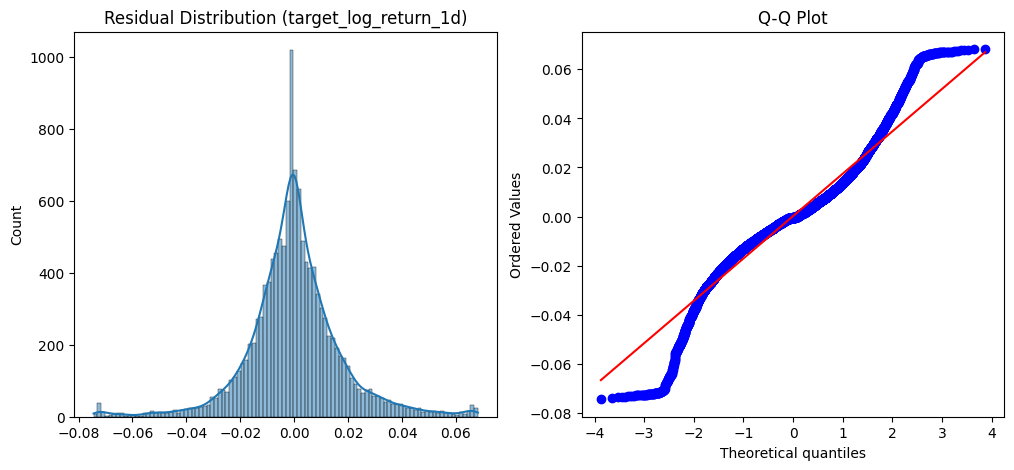

Evaluating Target: target_log_return_5d
Warning (AssertionError): White test failed for target_log_return_5d fold 1 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_5d fold 2 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_5d fold 3 due to matrix rank issues. Exog shape: (4285, 33). Error: 


,Fold,MSE,RMSE,MAE,MAPE,R2,DW_Stat,LjungBox_p,White_p,Target
0,1,0.001467,0.038297,0.02840,8.220425e+11,-0.000584,1.260336,0.0,NaN,target_log_return_5d
1,2,0.001593,0.039914,0.02886,1.525481e+11,0.006476,1.171529,0.0,NaN,target_log_return_5d
2,3,0.001811,0.042556,0.02881,3.285104e+11,0.003910,1.499029,0.0,NaN,target_log_return_5d


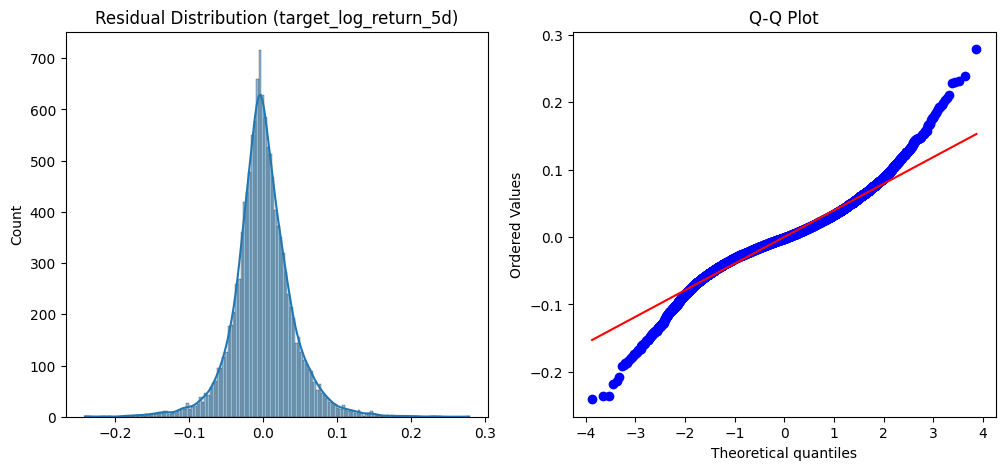

Evaluating Target: target_log_return_20d
Warning (AssertionError): White test failed for target_log_return_20d fold 1 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_20d fold 2 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_20d fold 3 due to matrix rank issues. Exog shape: (4285, 33). Error: 


,Fold,MSE,RMSE,MAE,MAPE,R2,DW_Stat,LjungBox_p,White_p,Target
0,1,0.005979,0.077321,0.058920,1.256233e+12,0.001686,1.189042,0.0,NaN,target_log_return_20d
1,2,0.006853,0.082785,0.061050,7.276661e+11,-0.002156,1.194924,0.0,NaN,target_log_return_20d
2,3,0.008090,0.089945,0.060611,3.927481e+11,-0.009285,1.617271,0.0,NaN,target_log_return_20d


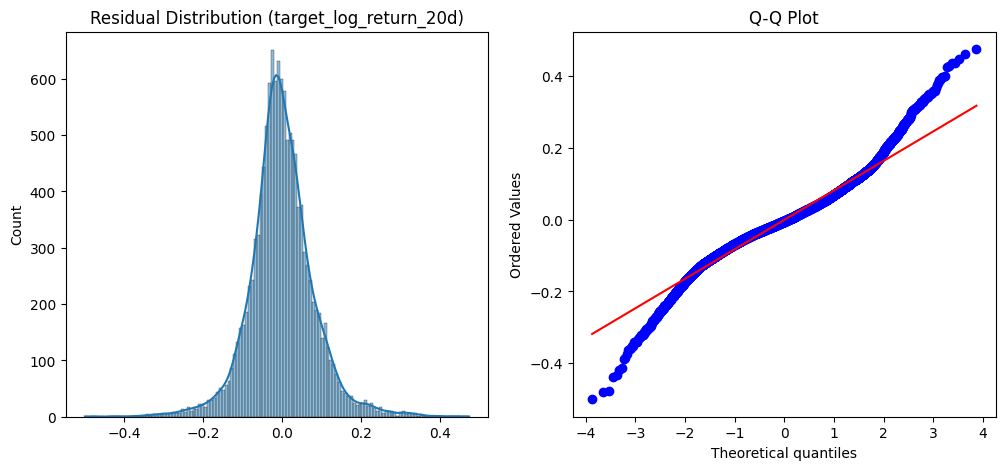


--- Overall Performance Summary (Fold-wise) ---


,Fold,MSE,RMSE,MAE,MAPE,R2,DW_Stat,LjungBox_p,White_p,Target
0,1,0.000293,0.017110,0.011992,1.865402e+11,-0.000702,1.405719,7.375339e-111,NaN,target_log_return_1d
1,2,0.000335,0.018306,0.012536,3.060081e+11,-0.000232,1.315773,1.063954e-159,NaN,target_log_return_1d
2,3,0.000320,0.017883,0.011954,1.379966e+11,0.003117,1.499136,1.826065e-101,NaN,target_log_return_1d
3,1,0.001467,0.038297,0.028400,8.220425e+11,-0.000584,1.260336,0.000000e+00,NaN,target_log_return_5d
4,2,0.001593,0.039914,0.028860,1.525481e+11,0.006476,1.171529,0.000000e+00,NaN,target_log_return_5d
5,3,0.001811,0.042556,0.028810,3.285104e+11,0.003910,1.499029,0.000000e+00,NaN,target_log_return_5d
6,1,0.005979,0.077321,0.058920,1.256233e+12,0.001686,1.189042,0.000000e+00,NaN,target_log_return_20d
7,2,0.006853,0.082785,0.061050,7.276661e+11,-0.002156,1.194924,0.000000e+00,NaN,target_log_return_20d
8,3,0.008090,0.089945,0.060611,3.927481e+11,-0.009285,1.617271,0.000000e+00,NaN,target_log_return_20d


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats # Ensure scipy.stats is imported for Q-Q plot

# Evaluation for the target days
target_full_names = ['target_log_return_1d', 'target_log_return_5d', 'target_log_return_20d']

all_eval_metrics_df_list = [] # List to store DataFrames for each target day
all_target_residuals = {} # Dictionary to store all residuals for each target day

for full_name in target_full_names:
    key_num = full_name.replace('target_log_return_', '').replace('d', '')
    target_key_for_dict = f'target_{key_num}d'

    if target_key_for_dict not in best_estimators_per_target_and_fold:
        print(f"Skipping evaluation for {full_name} as no model found (training might have been interrupted).")
        continue

    eval_metrics, residuals = evaluate_model(full_name, best_estimators_per_target_and_fold[target_key_for_dict], all_df, tscv, dates)
    # Add a column to identify the target day
    eval_metrics['Target'] = full_name
    all_eval_metrics_df_list.append(eval_metrics)
    all_target_residuals[full_name] = residuals # Store residuals for current target

    display(eval_metrics)

    # Visualization of Residuals
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(residuals, kde=True)
    plt.title(f'Residual Distribution ({full_name})')

    plt.subplot(1, 2, 2)
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('Q-Q Plot')
    plt.show()

# Combine all evaluation metrics into a single DataFrame
if all_eval_metrics_df_list:
    summary_table = pd.concat(all_eval_metrics_df_list, ignore_index=True)
    print("\n--- Overall Performance Summary (Fold-wise) ---")
    display(summary_table)
else:
    print("No evaluation metrics to display.")


In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats

if 'summary_table' in locals() and summary_table is not None and \
   'all_target_residuals' in locals() and all_target_residuals is not None:

    print("\n Summary Analysis for All Target Days")

    for target_name in summary_table['Target'].unique():
        if target_name in all_target_residuals:
            target_residuals = all_target_residuals[target_name]
            target_summary_df = summary_table[summary_table['Target'] == target_name]

            if not target_summary_df.empty:
                avg_r2 = target_summary_df['R2'].mean()
                avg_dw = target_summary_df['DW_Stat'].mean()
                avg_lb_p = target_summary_df['LjungBox_p'].mean()
                avg_white_p = target_summary_df['White_p'].mean()

                std_resid = np.std(target_residuals)
                margin_of_error = 1.96 * std_resid

                print(f"\nFor Target: {target_name}")
                print(f"  95% Prediction Confidence Interval Margin: +/- {margin_of_error:.4f} (log-return)")
                print(f"  Average R2: {avg_r2:.4f}")
                print(f"  Average Durbin-Watson: {avg_dw:.4f}")
                print(f"  Average Ljung-Box p-value: {avg_lb_p:.4f}")
                print(f"  Average White Test p-value: {avg_white_p:.4f}")
            else:
                print(f"\nNo evaluation metrics found for target: {target_name}")
        else:
            print(f"\nNo residuals found for target: {target_name}")
else:
    print("Evaluation results (summary_table and all_target_residuals) not available. Please run the evaluation cell successfully first.")



--- Summary Analysis for All Target Days ---

For Target: target_log_return_1d
  95% Prediction Confidence Interval Margin: +/- 0.0348 (log-return)
  Average R2: 0.0007
  Average Durbin-Watson: 1.4069 (Values near 2 indicate no autocorrelation)
  Average Ljung-Box p-value: 0.0000 (p > 0.05 suggests residuals are white noise)
  Average White Test p-value: nan (p < 0.05 suggests heteroskedasticity)

For Target: target_log_return_5d
  95% Prediction Confidence Interval Margin: +/- 0.0790 (log-return)
  Average R2: 0.0033
  Average Durbin-Watson: 1.3103 (Values near 2 indicate no autocorrelation)
  Average Ljung-Box p-value: 0.0000 (p > 0.05 suggests residuals are white noise)
  Average White Test p-value: nan (p < 0.05 suggests heteroskedasticity)

For Target: target_log_return_20d
  95% Prediction Confidence Interval Margin: +/- 0.1637 (log-return)
  Average R2: -0.0033
  Average Durbin-Watson: 1.3337 (Values near 2 indicate no autocorrelation)
  Average Ljung-Box p-value: 0.0000 (p > 0

## Evaluation - SVR and XGBoost Ensemble

This section integrates an XGBoost model with the existing SVR model to form an ensemble. We will train both models and average their predictions to potentially improve forecasting performance.

In [ ]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from scipy import stats
import pandas as pd
import xgboost as xgb

param_distributions_svr = {
    "svr__kernel": ["rbf", "linear", "poly"],
    "svr__C": stats.loguniform(0.01, 100),
    "svr__epsilon": stats.uniform(0.001, 0.5),
    "svr__gamma": ["scale", "auto"] + list(stats.loguniform(0.0001, 1).rvs(5))
}

param_distributions_xgb = {
    'xgbregressor__n_estimators': stats.randint(50, 300),
    'xgbregressor__learning_rate': stats.loguniform(0.01, 0.3),
    'xgbregressor__max_depth': stats.randint(3, 10),
    'xgbregressor__subsample': stats.uniform(0.6, 0.4),
    'xgbregressor__colsample_bytree': stats.uniform(0.6, 0.4),
    'xgbregressor__gamma': stats.loguniform(1e-3, 1),
    'xgbregressor__min_child_weight': stats.loguniform(1, 10)
}

def get_label(train_df:pd.DataFrame, day:int = 20):
    target_cols = ["target_log_return_1d", "target_log_return_5d", "target_log_return_20d"]
    non_feature_cols = ["stock_code", "trading_date", "ticker"] + target_cols
    features = [col for col in train_df.columns if col not in non_feature_cols]
    train_data = train_df[features]
    label = train_df[f"target_log_return_{day}d"]
    return train_data, label

def get_pipeline(scaler, model):
    return make_pipeline(scaler, model)

def train_svr_ensemble(X_train: pd.DataFrame, y_train: pd.DataFrame, scaler, model, param_distributions):
    pipeline = get_pipeline(scaler, model)
    random_search = RandomizedSearchCV(pipeline, param_distributions, n_iter=75, cv=None, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0, random_state=42)
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_

def train_xgb_ensemble(X_train: pd.DataFrame, y_train: pd.DataFrame, scaler, model, param_distributions):
    pipeline = get_pipeline(scaler, model)
    random_search = RandomizedSearchCV(pipeline, param_distributions, n_iter=50, cv=None, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0, random_state=42)
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_

### Training SVR and XGBoost Ensemble Models

In [ ]:
import warnings
warnings.filterwarnings('ignore')

days_to_predict = [1, 5, 20]
scaler = MinMaxScaler((0,1))
svr_model_base = SVR()
xgb_model_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

best_ensemble_models_per_target_and_fold = {}
for day in days_to_predict:
    print(f"\nTraining for target: target_log_return_{day}d")
    best_models_for_current_target = {}

    for fold, (train_date_idx, test_date_idx) in enumerate(tscv.split(dates)):
        train_dates = dates[train_date_idx]
        train_df_fold = all_df[all_df["trading_date"].isin(train_dates)].copy()

        X_train, y_train = get_label(train_df_fold, day=day)
        print(f"  Fold {fold+1}: Training with {len(X_train)} samples for target_log_return_{day}d")

        best_svr_estimator = train_svr_ensemble(X_train, y_train, scaler, svr_model_base, param_distributions_svr)
        print(f"    SVR Fold {fold+1} Best Parameters: {best_svr_estimator.named_steps['svr'].get_params()}")

        best_xgb_estimator = train_xgb_ensemble(X_train, y_train, scaler, xgb_model_base, param_distributions_xgb)
        print(f"    XGB Fold {fold+1} Best Parameters: {best_xgb_estimator.named_steps['xgbregressor'].get_params()}")

        best_models_for_current_target[f"fold_{fold+1}"] = {
            'svr': best_svr_estimator,
            'xgb': best_xgb_estimator
        }

    best_ensemble_models_per_target_and_fold[f"target_{day}d"] = best_models_for_current_target

print("\nTraining complete! Best ensemble estimators stored in 'best_ensemble_models_per_target_and_fold'.")


Training for target: target_log_return_1d
  Fold 1: Training with 4200 samples for target_log_return_1d
    SVR Fold 1 Best Parameters: {'C': np.float64(0.012637946338082878), 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': np.float64(0.054945713496652226), 'gamma': np.float64(0.0522116035734316), 'kernel': 'poly', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}
    XGB Fold 1 Best Parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': np.float64(0.637469907131237), 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': np.float64(0.012680822080429411), 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': np.float64(0.02464541037732725), 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot'

### Ensemble Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white
import scipy.stats as stats
import statsmodels.api as sm
import pandas as pd
import numpy as np

def evaluate_ensemble_model(target_day_full_name, best_ensemble_models_dict, all_df, tscv, dates):
    results = []
    all_residuals = []

    print(f"Evaluating Target: {target_day_full_name}")
    day_num = int(target_day_full_name.replace('target_log_return_', '').replace('d', ''))

    for fold, (train_idx, test_idx) in enumerate(tscv.split(dates)):
        test_dates_fold = dates[test_idx]
        test_df_fold = all_df[all_df['trading_date'].isin(test_dates_fold)].copy()
        X_test, y_true = get_label(test_df_fold, day=day_num)

        svr_model = best_ensemble_models_dict[f'fold_{fold+1}']['svr']
        xgb_model = best_ensemble_models_dict[f'fold_{fold+1}']['xgb']

        y_pred_svr = svr_model.predict(X_test)
        y_pred_xgb = xgb_model.predict(X_test)
        y_pred = (y_pred_svr + y_pred_xgb) / 2

        # Basic Metrics
        mse = mean_squared_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred) if not y_true.empty else float('nan')
        r2 = r2_score(y_true, y_pred)

        # Residuals
        residuals = y_true - y_pred
        all_residuals.extend(residuals)

        # Prepare X_test for White Test
        X_test_for_white = X_test.select_dtypes(include=np.number).copy()
        for col in X_test_for_white.columns:
            if X_test_for_white[col].nunique(dropna=False) <= 1:
                X_test_for_white = X_test_for_white.drop(columns=[col])

        X_test_with_const = None
        if X_test_for_white.shape[1] > 0:
            X_test_with_const = sm.add_constant(X_test_for_white, has_constant='add', prepend=False)
        else:
            X_test_with_const = pd.DataFrame(index=X_test.index, data={'const': 1}) if not X_test.empty else pd.DataFrame()

        residuals_clean = pd.Series(residuals)
        if not X_test_with_const.empty:
            combined_data = pd.concat([X_test_with_const, residuals_clean.rename('residuals')], axis=1).dropna()
            X_test_with_const_clean = combined_data.drop(columns=['residuals'])
            residuals_clean = combined_data['residuals']
        else:
            X_test_with_const_clean = pd.DataFrame()
            residuals_clean = pd.Series([])

        # Durbin-Watson
        dw = durbin_watson(residuals)

        # Ljung-Box (H0: residuals are independent)
        lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
        lb_pvalue = lb_test['lb_pvalue'].values[0]

        # White Test for Heteroskedasticity
        white_pvalue = float('nan')
        try:
            if X_test_with_const_clean.shape[1] > 1 and not residuals_clean.empty and len(residuals_clean) > X_test_with_const_clean.shape[1]:
                white_test = het_white(residuals_clean, X_test_with_const_clean)
                white_pvalue = white_test[1]
            else:
                print(f"Warning: White test skipped for {target_day_full_name} fold {fold+1} due to insufficient valid features, empty residuals after cleaning, or too few observations. Exog shape: {X_test_with_const_clean.shape}, Residuals count: {len(residuals_clean)}")
        except AssertionError as e:
            print(f"Warning (AssertionError): White test failed for {target_day_full_name} fold {fold+1} due to matrix rank issues. Exog shape: {X_test_with_const_clean.shape}. Error: {e}")
        except Exception as e:
            print(f"Warning (Other Error): White test failed for {target_day_full_name} fold {fold+1}: {e}")

        results.append({
            'Fold': fold + 1,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'R2': r2,
            'DW_Stat': dw,
            'LjungBox_p': lb_pvalue,
            'White_p': white_pvalue
        })

    return pd.DataFrame(results), np.array(all_residuals)

Evaluating Target: target_log_return_1d
Warning (AssertionError): White test failed for target_log_return_1d fold 1 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_1d fold 2 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_1d fold 3 due to matrix rank issues. Exog shape: (4285, 33). Error: 


,Fold,MSE,RMSE,MAE,MAPE,R2,DW_Stat,LjungBox_p,White_p,Target
0,1,0.000310,0.017602,0.012526,9.194628e+11,-0.059103,1.407871,3.004698e-104,NaN,target_log_return_1d
1,2,0.000333,0.018262,0.012473,1.710534e+11,0.004592,1.309702,1.319249e-169,NaN,target_log_return_1d
2,3,0.000320,0.017883,0.011993,2.383903e+11,0.003174,1.505523,5.548167e-102,NaN,target_log_return_1d


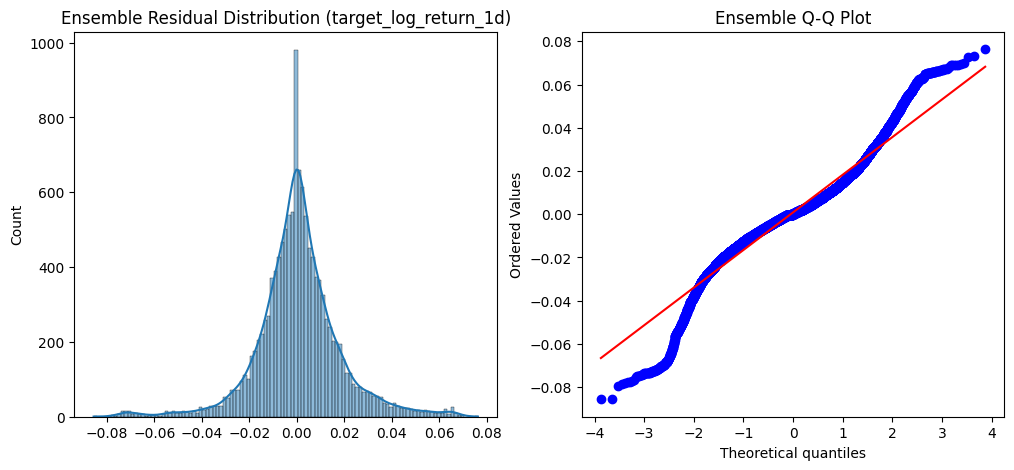

Evaluating Target: target_log_return_5d
Warning (AssertionError): White test failed for target_log_return_5d fold 1 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_5d fold 2 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_5d fold 3 due to matrix rank issues. Exog shape: (4285, 33). Error: 


,Fold,MSE,RMSE,MAE,MAPE,R2,DW_Stat,LjungBox_p,White_p,Target
0,1,0.001521,0.039000,0.029164,8.963960e+11,-0.037631,1.293710,0.0,NaN,target_log_return_5d
1,2,0.001595,0.039940,0.028983,2.919297e+11,0.005179,1.173660,0.0,NaN,target_log_return_5d
2,3,0.001828,0.042757,0.028834,2.459231e+11,-0.005536,1.505306,0.0,NaN,target_log_return_5d


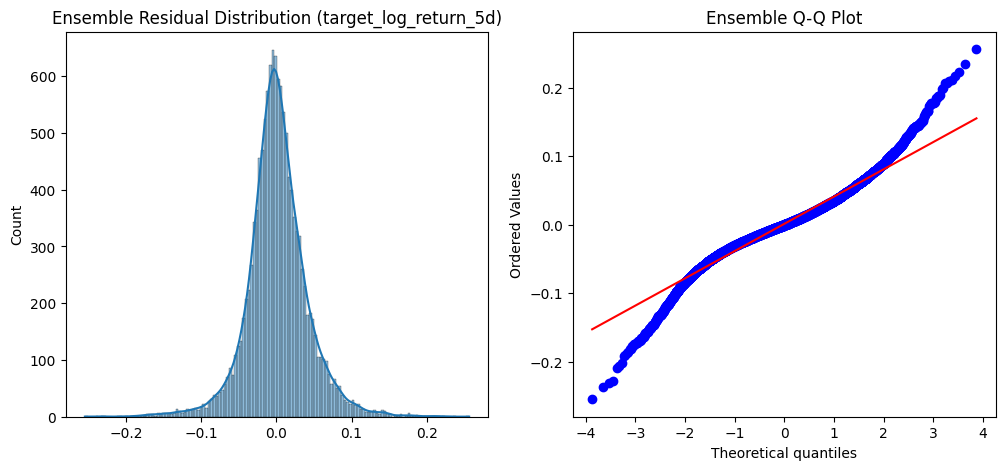

Evaluating Target: target_log_return_20d
Warning (AssertionError): White test failed for target_log_return_20d fold 1 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_20d fold 2 due to matrix rank issues. Exog shape: (4285, 33). Error: 
Warning (AssertionError): White test failed for target_log_return_20d fold 3 due to matrix rank issues. Exog shape: (4285, 33). Error: 


,Fold,MSE,RMSE,MAE,MAPE,R2,DW_Stat,LjungBox_p,White_p,Target
0,1,0.005985,0.077362,0.058926,1.196699e+12,0.000633,1.190693,0.0,NaN,target_log_return_20d
1,2,0.006918,0.083173,0.061525,7.833589e+11,-0.011570,1.194344,0.0,NaN,target_log_return_20d
2,3,0.008081,0.089895,0.060890,4.375517e+11,-0.008158,1.611933,0.0,NaN,target_log_return_20d


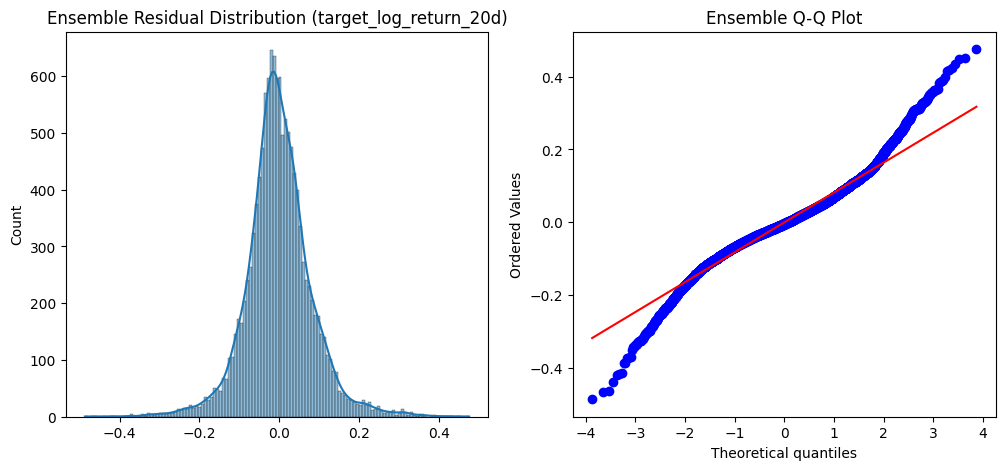


--- Overall Performance Summary (Ensemble Fold-wise) ---


,Fold,MSE,RMSE,MAE,MAPE,R2,DW_Stat,LjungBox_p,White_p,Target
0,1,0.000310,0.017602,0.012526,9.194628e+11,-0.059103,1.407871,3.004698e-104,NaN,target_log_return_1d
1,2,0.000333,0.018262,0.012473,1.710534e+11,0.004592,1.309702,1.319249e-169,NaN,target_log_return_1d
2,3,0.000320,0.017883,0.011993,2.383903e+11,0.003174,1.505523,5.548167e-102,NaN,target_log_return_1d
3,1,0.001521,0.039000,0.029164,8.963960e+11,-0.037631,1.293710,0.000000e+00,NaN,target_log_return_5d
4,2,0.001595,0.039940,0.028983,2.919297e+11,0.005179,1.173660,0.000000e+00,NaN,target_log_return_5d
5,3,0.001828,0.042757,0.028834,2.459231e+11,-0.005536,1.505306,0.000000e+00,NaN,target_log_return_5d
6,1,0.005985,0.077362,0.058926,1.196699e+12,0.000633,1.190693,0.000000e+00,NaN,target_log_return_20d
7,2,0.006918,0.083173,0.061525,7.833589e+11,-0.011570,1.194344,0.000000e+00,NaN,target_log_return_20d
8,3,0.008081,0.089895,0.060890,4.375517e+11,-0.008158,1.611933,0.000000e+00,NaN,target_log_return_20d


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

target_full_names = ['target_log_return_1d', 'target_log_return_5d', 'target_log_return_20d']

all_eval_metrics_df_ensemble_list = []
all_target_residuals_ensemble = {}

for full_name in target_full_names:
    key_num = full_name.replace('target_log_return_', '').replace('d', '')
    target_key_for_dict = f'target_{key_num}d'

    if target_key_for_dict not in best_ensemble_models_per_target_and_fold:
        print(f"Skipping evaluation for {full_name} as no ensemble model found.")
        continue

    eval_metrics_ensemble, residuals_ensemble = evaluate_ensemble_model(full_name, best_ensemble_models_per_target_and_fold[target_key_for_dict], all_df, tscv, dates)
    eval_metrics_ensemble['Target'] = full_name
    all_eval_metrics_df_ensemble_list.append(eval_metrics_ensemble)
    all_target_residuals_ensemble[full_name] = residuals_ensemble

    display(eval_metrics_ensemble)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(residuals_ensemble, kde=True)
    plt.title(f'Ensemble Residual Distribution ({full_name})')

    plt.subplot(1, 2, 2)
    stats.probplot(residuals_ensemble, dist="norm", plot=plt)
    plt.title('Ensemble Q-Q Plot')
    plt.show()

if all_eval_metrics_df_ensemble_list:
    summary_table_ensemble = pd.concat(all_eval_metrics_df_ensemble_list, ignore_index=True)
    print("\n--- Overall Performance Summary (Ensemble Fold-wise) ---")
    display(summary_table_ensemble)
else:
    print("No ensemble evaluation metrics to display.")

### Summary Analysis for SVR + XGBoost Ensemble

In [48]:
import numpy as np
import pandas as pd
import scipy.stats as stats

if 'summary_table_ensemble' in locals() and summary_table_ensemble is not None and \
   'all_target_residuals_ensemble' in locals() and all_target_residuals_ensemble is not None:

    print("\n--- Summary Analysis for SVR + XGBoost Ensemble Across All Target Days ---")

    for target_name in summary_table_ensemble['Target'].unique():
        if target_name in all_target_residuals_ensemble:
            target_residuals = all_target_residuals_ensemble[target_name]
            target_summary_df = summary_table_ensemble[summary_table_ensemble['Target'] == target_name]

            if not target_summary_df.empty:
                avg_r2 = target_summary_df['R2'].mean()
                avg_dw = target_summary_df['DW_Stat'].mean()
                avg_lb_p = target_summary_df['LjungBox_p'].mean()
                avg_white_p = target_summary_df['White_p'].mean()

                std_resid = np.std(target_residuals)
                margin_of_error = 1.96 * std_resid

                print(f"\nFor Target: {target_name} (Ensemble)")
                print(f"  95% Prediction Confidence Interval Margin: +/- {margin_of_error:.4f} (log-return)")
                print(f"  Average R2: {avg_r2:.4f}")
                print(f"  Average Durbin-Watson: {avg_dw:.4f}")
                print(f"  Average Ljung-Box p-value: {avg_lb_p:.4f}")
                print(f"  Average White Test p-value: {avg_white_p:.4f}")
            else:
                print(f"\nNo ensemble evaluation metrics found for target: {target_name}")
        else:
            print(f"\nNo ensemble residuals found for target: {target_name}")
else:
    print("Ensemble evaluation results (summary_table_ensemble and all_target_residuals_ensemble) not available. Please run the ensemble evaluation cell successfully first.")


--- Summary Analysis for SVR + XGBoost Ensemble Across All Target Days ---

For Target: target_log_return_1d (Ensemble)
  95% Prediction Confidence Interval Margin: +/- 0.0351 (log-return)
  Average R2: -0.0171
  Average Durbin-Watson: 1.4077
  Average Ljung-Box p-value: 0.0000
  Average White Test p-value: nan

For Target: target_log_return_5d (Ensemble)
  95% Prediction Confidence Interval Margin: +/- 0.0795 (log-return)
  Average R2: -0.0127
  Average Durbin-Watson: 1.3242
  Average Ljung-Box p-value: 0.0000
  Average White Test p-value: nan

For Target: target_log_return_20d (Ensemble)
  95% Prediction Confidence Interval Margin: +/- 0.1639 (log-return)
  Average R2: -0.0064
  Average Durbin-Watson: 1.3323
  Average Ljung-Box p-value: 0.0000
  Average White Test p-value: nan


In [51]:
import os
import numpy as np
import pandas as pd

# Define base prediction directories
BASE_PREDICTIONS_DIR = Path("/content") / "predictions"
SVR_PREDICTIONS_DIR = BASE_PREDICTIONS_DIR / "svr"
XGB_PREDICTIONS_DIR = BASE_PREDICTIONS_DIR / "xgb"

# Create directories if they don't exist
SVR_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
XGB_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

# Get the test dates for the last fold (fold 3)
tscv_iterator = tscv.split(dates)
for fold_idx, (train_date_idx, test_date_idx) in enumerate(tscv_iterator):
    if fold_idx == 2: # This is the third fold (0-indexed)
        test_dates_fold_3 = dates[test_date_idx]
        break

# Filter all_df to get the test data for the last fold
test_df_fold_3 = all_df[all_df["trading_date"].isin(test_dates_fold_3)].copy()

for ticker in tickers:
    print(f"\nGenerating predictions for ticker: {ticker}")

    ticker_data_for_prediction = test_df_fold_3[test_df_fold_3['ticker'] == ticker].copy()

    if ticker_data_for_prediction.empty:
        print(f"  No test data found for ticker {ticker} in fold 3. Skipping.")
        continue

    # Create ticker-specific subdirectories
    svr_ticker_log_return_dir = SVR_PREDICTIONS_DIR / ticker / "log_return"
    svr_ticker_log_close_dir = SVR_PREDICTIONS_DIR / ticker / "log_close"
    xgb_ticker_log_return_dir = XGB_PREDICTIONS_DIR / ticker / "log_return"
    xgb_ticker_log_close_dir = XGB_PREDICTIONS_DIR / ticker / "log_close"

    svr_ticker_log_return_dir.mkdir(parents=True, exist_ok=True)
    svr_ticker_log_close_dir.mkdir(parents=True, exist_ok=True)
    xgb_ticker_log_return_dir.mkdir(parents=True, exist_ok=True)
    xgb_ticker_log_close_dir.mkdir(parents=True, exist_ok=True)

    for day in days_to_predict:
        target_full_name = f'target_log_return_{day}d'
        target_key_for_dict = f'target_{day}d'

        if target_key_for_dict not in best_ensemble_models_per_target_and_fold:
            print(f"    Skipping {target_full_name} for {ticker} as no ensemble model found.")
            continue

        # Prepare features (X_test) and actual log-return values (y_true)
        X_test, y_true_log_return = get_label(ticker_data_for_prediction, day=day)

        # Get original `log_close` corresponding to X_test indices
        current_log_close = ticker_data_for_prediction.loc[X_test.index, 'log_close']
        actual_log_close_future = ticker_data_for_prediction.loc[X_test.index, 'log_close'].shift(-day)

        # Align all data to non-NaN future log_close indices
        common_indices = actual_log_close_future.dropna().index
        if common_indices.empty:
            print(f"    No valid future log_close data for {target_full_name} for {ticker} after alignment. Skipping.")
            continue

        current_log_close_aligned = current_log_close.loc[common_indices]
        y_true_log_return_aligned = y_true_log_return.loc[common_indices]
        X_test_aligned = X_test.loc[common_indices]
        ds_aligned = ticker_data_for_prediction.loc[common_indices, 'trading_date']
        actual_log_close_future_aligned = actual_log_close_future.loc[common_indices]

        # --- SVR Model Predictions ---
        svr_model = best_ensemble_models_per_target_and_fold[target_key_for_dict]['fold_3']['svr']
        yhat_svr_log_return = svr_model.predict(X_test_aligned)
        residuals_svr = y_true_log_return_aligned - yhat_svr_log_return
        std_resid_svr = np.std(residuals_svr)
        margin_of_error_svr = 1.96 * std_resid_svr # 95% confidence interval

        yhat_lower_svr_log_return = yhat_svr_log_return - margin_of_error_svr
        yhat_upper_svr_log_return = yhat_svr_log_return + margin_of_error_svr

        # Log-Return CSV for SVR
        df_svr_log_return = pd.DataFrame({
            'ds': ds_aligned,
            'y': y_true_log_return_aligned,
            'yhat': yhat_svr_log_return,
            'yhat_lower': yhat_lower_svr_log_return,
            'yhat_upper': yhat_upper_svr_log_return
        })
        df_svr_log_return.to_csv(svr_ticker_log_return_dir / f"{day}d_predictions.csv", index=False)
        print(f"    SVR Log-Return {day}d predictions for {ticker} saved.")

        # Derive Log-Close predictions for SVR
        yhat_svr_log_close = current_log_close_aligned + yhat_svr_log_return
        yhat_lower_svr_log_close = current_log_close_aligned + yhat_lower_svr_log_return
        yhat_upper_svr_log_close = current_log_close_aligned + yhat_upper_svr_log_return

        # Log-Close CSV for SVR
        df_svr_log_close = pd.DataFrame({
            'ds': ds_aligned,
            'y': actual_log_close_future_aligned,
            'yhat': yhat_svr_log_close,
            'yhat_lower': yhat_lower_svr_log_close,
            'yhat_upper': yhat_upper_svr_log_close
        })
        df_svr_log_close.to_csv(svr_ticker_log_close_dir / f"{day}d_predictions.csv", index=False)
        print(f"    SVR Log-Close {day}d predictions for {ticker} saved.")

        # --- XGBoost Model Predictions ---
        xgb_model = best_ensemble_models_per_target_and_fold[target_key_for_dict]['fold_3']['xgb']
        yhat_xgb_log_return = xgb_model.predict(X_test_aligned)
        residuals_xgb = y_true_log_return_aligned - yhat_xgb_log_return
        std_resid_xgb = np.std(residuals_xgb)
        margin_of_error_xgb = 1.96 * std_resid_xgb # 95% confidence interval

        yhat_lower_xgb_log_return = yhat_xgb_log_return - margin_of_error_xgb
        yhat_upper_xgb_log_return = yhat_xgb_log_return + margin_of_error_xgb

        # Log-Return CSV for XGBoost
        df_xgb_log_return = pd.DataFrame({
            'ds': ds_aligned,
            'y': y_true_log_return_aligned,
            'yhat': yhat_xgb_log_return,
            'yhat_lower': yhat_lower_xgb_log_return,
            'yhat_upper': yhat_upper_xgb_log_return
        })
        df_xgb_log_return.to_csv(xgb_ticker_log_return_dir / f"{day}d_predictions.csv", index=False)
        print(f"    XGB Log-Return {day}d predictions for {ticker} saved.")

        # Derive Log-Close predictions for XGBoost
        yhat_xgb_log_close = current_log_close_aligned + yhat_xgb_log_return
        yhat_lower_xgb_log_close = current_log_close_aligned + yhat_lower_xgb_log_return
        yhat_upper_xgb_log_close = current_log_close_aligned + yhat_upper_xgb_log_return

        # Log-Close CSV for XGBoost
        df_xgb_log_close = pd.DataFrame({
            'ds': ds_aligned,
            'y': actual_log_close_future_aligned,
            'yhat': yhat_xgb_log_close,
            'yhat_lower': yhat_lower_xgb_log_close,
            'yhat_upper': yhat_upper_xgb_log_close
        })
        df_xgb_log_close.to_csv(xgb_ticker_log_close_dir / f"{day}d_predictions.csv", index=False)
        print(f"    XGB Log-Close {day}d predictions for {ticker} saved.")

print("\nAll individual model predictions generated and saved.")


Generating predictions for ticker: FPT
    SVR Log-Return 1d predictions for FPT saved.
    SVR Log-Close 1d predictions for FPT saved.
    XGB Log-Return 1d predictions for FPT saved.
    XGB Log-Close 1d predictions for FPT saved.
    SVR Log-Return 5d predictions for FPT saved.
    SVR Log-Close 5d predictions for FPT saved.
    XGB Log-Return 5d predictions for FPT saved.
    XGB Log-Close 5d predictions for FPT saved.
    SVR Log-Return 20d predictions for FPT saved.
    SVR Log-Close 20d predictions for FPT saved.
    XGB Log-Return 20d predictions for FPT saved.
    XGB Log-Close 20d predictions for FPT saved.

Generating predictions for ticker: HPG
    SVR Log-Return 1d predictions for HPG saved.
    SVR Log-Close 1d predictions for HPG saved.
    XGB Log-Return 1d predictions for HPG saved.
    XGB Log-Close 1d predictions for HPG saved.
    SVR Log-Return 5d predictions for HPG saved.
    SVR Log-Close 5d predictions for HPG saved.
    XGB Log-Return 5d predictions for HPG s